# Lunar Flyby — Part 1: the two-body problem

*DSECOP module for the Kepler's-laws unit of classical mechanics — session 1 of 2.*

On April 1, 2026, four astronauts — the first crew beyond low Earth
orbit in more than fifty years — [launched on Artemis II](https://www.youtube.com/watch?v=Tf_UjBMIzNo)
and flew along a pre-computed path around the Moon and back, splashing down in the Pacific nine days
later. NASA's [mission page](https://www.nasa.gov/mission/artemis-ii/) and
[photo & footage gallery](https://www.nasa.gov/artemis-ii-multimedia/) tell the story. By the end of
Part 2 you will have reproduced on the computer a trajectory very similar to the real trajectory of Artemis II.

For the Artemis II flight, the gravitational pull of the Moon played an important role, slinging the spacecraft back to Earth. Today you will reproduce a simpler orbit first, not taking the Moon into account. This is a classic **Kepler orbit**, which you will also check against the theory from lecture or textbook.
In **Part 2** (next session) you will add the Moon and fly a **free-return lunar flyby**, the maneuver
NASA's crewed **Artemis II** flew in April 2026.


**How this works.** Go through this and next notebook like in a physics lab. Read each section, then do the actions in the notebook. The
*physics* is yours: you write the equations of motion. The *coding* (such as the numerical integrator below) you may not know, but you build **with an LLM** (Claude, ChatGPT, or Colab's Gemini) in a browser tab, pasting code into the cells. Keep the function names given below so the check cells work.

In [ ]:
# Setup (works as-is on Google Colab)
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## How to work with your LLM

When a cell says **"build with LLM,"** use prompts to have the code generated. Some pointers:

- **Give it the spec, not just "write code."** Paste the equation or the required function
  signature and say what the function must return.
- **Ask for comments.** Have the LLM annotate each line with a brief comment saying what it
  does, so you can follow code you did not write.
- **Note the exact interface the notebook expects** — e.g. `simulate(accel, r0, v0, dt, n)`
  returning `R, V` — so the check cells run unchanged.
- **Do not trust the output — run the check cells.** The diagnostics below (closed orbit,
  conserved energy, Kepler's third law) are your ground truth. If a check fails, the code is
  wrong, not the physics.
- **Keep going:** if you are stuck and time is short, ask your instructor for the reference
  version of the cell and keep going. Understanding and checking the result matters more than
  typing it from scratch.

## Visualize first (your first task with an LLM)

Before the physics, let's picture the scene. Below is a **sample orbit**: the Moon going around Earth, with the eccentricity exaggerated so Kepler's laws are easy to see. **Build with LLM:** use your LLM to *animate* it -- draw Earth and the Moon as simple icons and play the Moon along the path.

This is a good first job for an LLM: visualization is coding you may not know yet, and getting it working is a quick win. Keep your animation function -- you will reuse it on the orbit **you** compute later.

*Hints:* matplotlib's `FuncAnimation` with `HTML(anim.to_jshtml())` plays in Colab with no widgets. Draw Earth and the Moon as colored circles.

In [ ]:
# A sample orbit (Earth at the focus), from Kepler's equation so the timing is physical:
a, e = 0.84, 0.19                          # semi-major axis, eccentricity (exaggerated)
M = np.linspace(0, 2*np.pi, 400)           # mean anomaly (uniform in time)
E = M.copy()
for _ in range(50):
    E = M + e*np.sin(E)                    # solve Kepler's equation  M = E - e*sin(E)
R_sample = np.column_stack([a*(np.cos(E)-e), a*np.sqrt(1-e**2)*np.sin(E)])
print("R_sample shape:", R_sample.shape)

In [ ]:
# TODO (build with LLM): animate R_sample.
# Draw Earth and the Moon as icons, and play the Moon along the orbit.
# Hint: matplotlib FuncAnimation + HTML(anim.to_jshtml()) works in Colab.
# Hint: R_sample has 400 points -- use every 4th (~100 frames) so it renders in seconds and stays small.

## The two-body problem

A spacecraft of negligible mass moves under the gravity of a central body of mass $M$:
$$ \ddot{\mathbf r} = -\frac{GM}{r^{3}}\,\mathbf r . $$

**Nondimensionalize / scale.** Measure length in a scale $\ell$ and choose the time unit so that
$GM = 1$; the equation becomes parameter-free:
$$ \ddot{\mathbf r} = -\frac{\mathbf r}{r^{3}}. $$

A bound orbit is a **closed ellipse**, with conserved energy $E = \tfrac12 v^2 - 1/r$ and angular
momentum $L = x\dot y - y\dot x$, and **Kepler's third law** $T^2 = 4\pi^2 a^3$ (so $T^2/a^3 = 4\pi^2$
in these units).

**Before you build — the scaling (Q0).** Take the Earth–Moon distance $D = 384{,}400$ km as the
length unit $\ell$, with $GM_E = 3.986\times10^{5}\ \mathrm{km^3/s^2}$. Show that choosing the time unit
$\tau$ so that $GM_E = 1$ in scaled units forces $\tau = \sqrt{\ell^{3}/GM_E}$, and compute $\tau$ in
days. (You will meet this number again in Part 2, recomputed with the Earth–Moon distance *on the day*
and the combined Earth + Moon mass.)

*Your answer:*

> 


### Build with LLM

Implement two functions — the physics is yours, the code you may get from your LLM:

- `accel_2b(r, t)` — the scaled two-body acceleration (the equation above; it ignores `t`).
- `simulate(accel, r0, v0, dt, n)` — integrate $\ddot{\mathbf r} = \mathrm{accel}(\mathbf r, t)$ and
  return arrays `R, V` of shape `(n, 2)`. Ask your LLM for an **RK4** (or velocity-Verlet) step.
  Keep this exact signature so the checks below run — **you reuse `simulate` in Part 2.** Make it pass the *current time* `t` to `accel` at every
  step (even though `accel_2b` ignores it): Part 2's accelerations depend on `t`.

The interfaces at a glance. Hand them to your LLM as the spec: screenshot each diagram and paste the
image into the chat, or type out its bullets.

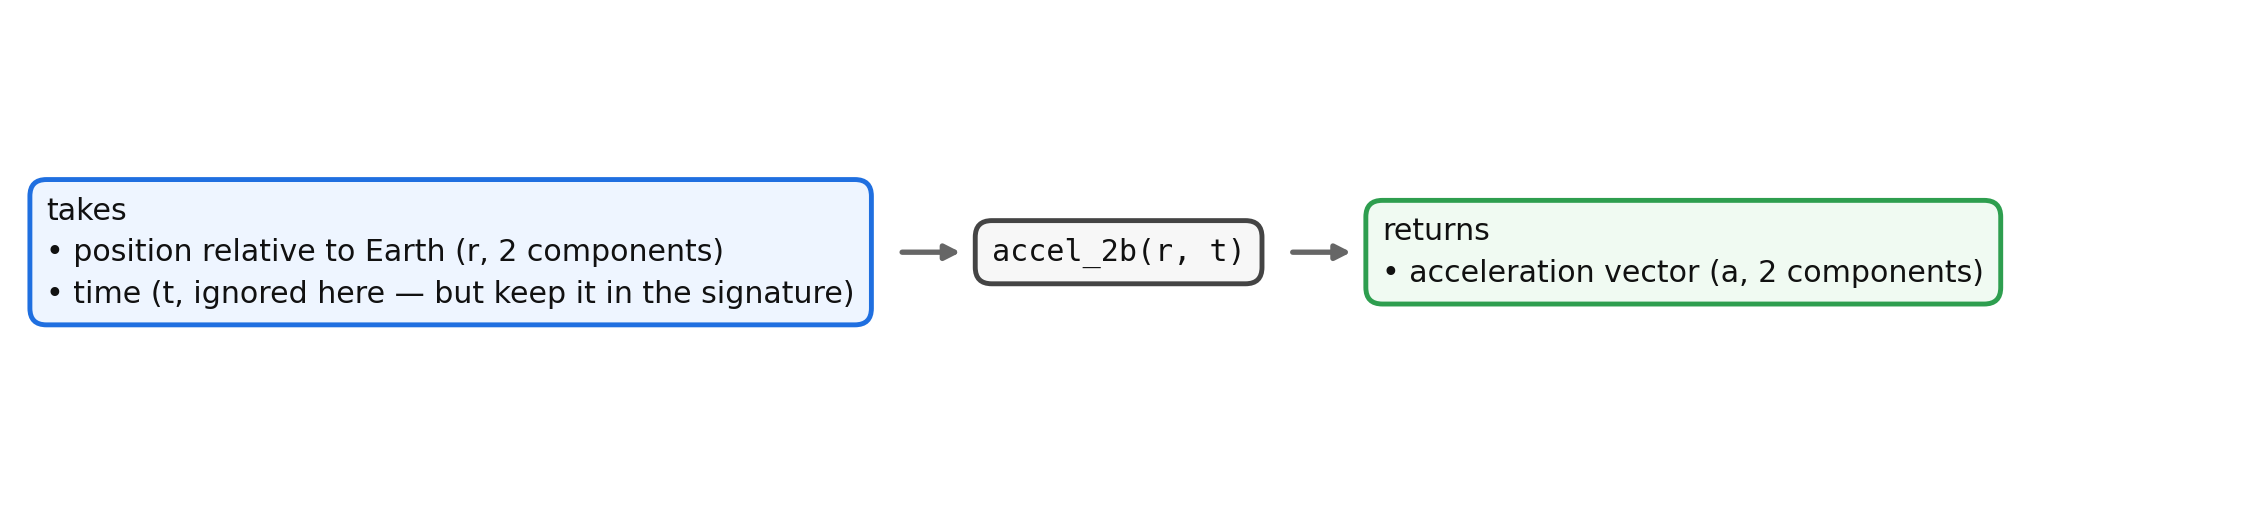

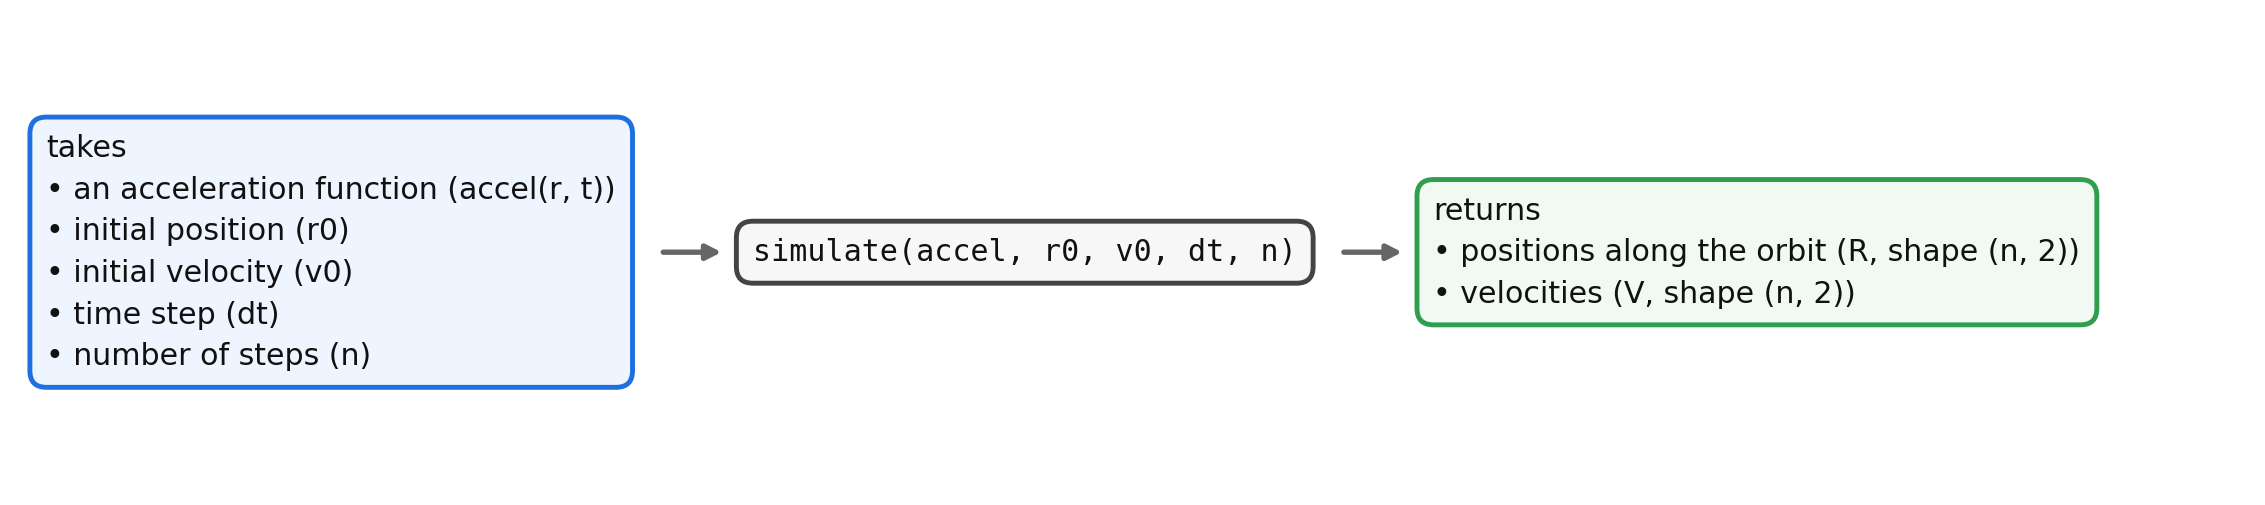

In [ ]:
# Replace this stub with your LLM's code (delete the raise line); keep the function name and signature.
def accel_2b(r, t):
    "Scaled two-body acceleration (GM=1). r is a length-2 array; t is unused."
    # TODO (build with LLM): the scaled two-body acceleration from the equation above.
    raise NotImplementedError

def simulate(accel, r0, v0, dt, n):
    "Integrate r'' = accel(r,t). Return R, V of shape (n,2)."
    # TODO (build with LLM): an RK4 or velocity-Verlet integrator with THIS signature.
    raise NotImplementedError

These diagnostics are **given** — use them to check your work.

In [ ]:
def energy(R, V):
    return 0.5*(V[:,0]**2 + V[:,1]**2) - 1.0/np.sqrt(R[:,0]**2 + R[:,1]**2)
def angmom(R, V):
    return R[:,0]*V[:,1] - R[:,1]*V[:,0]

**Check 1 — a closed ellipse.**

In [ ]:
r0 = np.array([1.0, 0.0]); v0 = np.array([0.0, 0.9])
E0 = 0.5*0.9**2 - 1.0; a_sma = -1/(2*E0); T = 2*np.pi*a_sma**1.5
R, V = simulate(accel_2b, r0, v0, T/2000, 4000)   # two periods
plt.figure(figsize=(4,4))
plt.plot(R[:,0], R[:,1]); plt.plot(0,0,'y*',ms=14); plt.plot(r0[0],r0[1],'go')
plt.gca().set_aspect('equal'); plt.grid(alpha=.3); plt.title('Two-body orbit'); plt.show()
# closed-orbit check (unambiguous pass/fail):
assert np.linalg.norm(R[2000] - r0) < 5e-3, 'orbit did not close -- check accel_2b/simulate'
print('PASS: orbit closes after one period.')

**Check 2 — conservation and numerical error.** Energy and angular momentum should be
constant; the small residual drift is *numerical* and should shrink as the step `dt` shrinks.

In [ ]:
E = energy(R, V); L = angmom(R, V)
print(f"energy drift    = {E.max()-E.min():.2e}")
print(f"ang.-mom. drift = {L.max()-L.min():.2e}")
for dt in [T/500, T/1000, T/2000, T/4000]:
    R2, V2 = simulate(accel_2b, r0, v0, dt, int(2*T/dt))
    E2 = energy(R2, V2)
    print(f"dt={dt:.2e}  energy drift={E2.max()-E2.min():.2e}")
assert (E.max() - E.min()) < 1e-5, 'energy not conserved -- check your integrator'
print('PASS: energy conserved (drift < 1e-5).')

**A question before you move on.** The drifts printed above are tiny but **not exactly zero** — yet
Check 2 says PASS. Why should a numerical conservation test never demand exactly zero? Where does the
leftover drift come from, and what about its behavior as `dt` shrinks convinces you the *physics* is
right anyway?

*Your answer:*

> 


**See it fail — forward Euler.** Before trusting any integrator, watch a bad one. Forward
Euler steps position and velocity using only the *current* values; on an orbit it quietly adds
energy, so the path spirals outward. (This is what Q1 below asks about.)

In [ ]:
def euler_step(accel, r0, v0, dt, n):
    R = np.empty((n, 2)); r = np.array(r0, float); v = np.array(v0, float)
    for i in range(n):
        R[i] = r
        a = accel(r, i*dt)          # pass the current time (as your simulate should)
        r = r + v*dt            # both updates use the OLD values -> energy creeps up
        v = v + a*dt
    return R

Re = euler_step(accel_2b, [1.0, 0.0], [0.0, 0.9], T/300, 1400)
plt.figure(figsize=(4, 4)); plt.plot(Re[:, 0], Re[:, 1], color="crimson", lw=1)
plt.plot(0, 0, 'o', color="#1f6fe0", ms=12); plt.gca().set_aspect('equal'); plt.grid(alpha=.3)
plt.title("Forward Euler spirals outward"); plt.show()

**Check 3 — Kepler's third law, measured from the simulation.** For several launch speeds,
measure the semi-major axis $a$ from the perigee and apogee your orbit *actually reaches*, and
the period $T$ from the time to go once around. Kepler's third law says $T^2/a^3$ is the same for
all of them — here, $4\pi^2$. (The analytic formulas are used only to pick the step size; $a$ and $T$ themselves are
measured from the trajectory.)

In [ ]:
def measure_a_T(vy):
    "Measure a (peri+apo)/2 and T (one revolution) from a simulated orbit launched at (1,0)."
    E = 0.5*vy*vy - 1.0; a0 = -1/(2*E); dt = 2*np.pi*a0**1.5/6000
    R, V = simulate(accel_2b, [1.0, 0.0], [0.0, vy], dt, int(2.2*2*np.pi*a0**1.5/dt))
    rmag = np.sqrt(R[:, 0]**2 + R[:, 1]**2)
    a = 0.5*(rmag.min() + rmag.max())                       # from the trajectory
    ang = np.abs(np.unwrap(np.arctan2(R[:, 1], R[:, 0])))   # starts at 0
    k = np.argmax(ang >= 2*np.pi)                            # first full revolution
    T = dt*((k-1) + (2*np.pi - ang[k-1])/(ang[k] - ang[k-1]))
    return a, T

print(f"Kepler's third law: T^2/a^3 should equal 4*pi^2 = {4*np.pi**2:.3f}")
ratios = []
for vy in [0.7, 0.8, 0.9, 1.0, 1.1]:
    a, T3 = measure_a_T(vy); ratios.append(T3*T3/a**3)
    print(f"  v0={vy:.2f}:  a={a:.4f}  T={T3:.4f}  T^2/a^3={T3*T3/a**3:.4f}")
assert np.allclose(ratios, 4*np.pi**2, rtol=3e-3), "Kepler III fails -- check accel_2b/simulate"
print("PASS: T^2/a^3 is constant to 0.3% (measured, not assumed).")

### Find the bug (LLM error hunt)

An LLM was asked for the two-body acceleration and produced the function below. Run it through your
checks (you can copy the above checks over here). The orbit and the diagnostics will tell you something is off. **Your job:** find the bug,
fix it, and say whether it is a *software* bug (a coding mistake) or a *physics* error (wrong
equation).

In [ ]:
def accel_buggy(r, t):
    # produced by an LLM -- something here is not right
    return -r / (r[0]**2 + r[1]**2)

Rb, Vb = simulate(accel_buggy, [1.0, 0.0], [0.0, 0.9], T/2000, 6000)
plt.figure(figsize=(4, 4)); plt.plot(Rb[:, 0], Rb[:, 1]); plt.plot(0, 0, 'o', color="#1f6fe0", ms=12)
plt.gca().set_aspect('equal'); plt.grid(alpha=.3); plt.title("accel_buggy -- does the orbit close?"); plt.show()
Eb = energy(Rb, Vb)
print(f"energy drift with this accel: {Eb.max()-Eb.min():.3g}   (compare with your Check 2 drift -- once fixed, they should match)")

Fix `accel_buggy` above and re-run until the orbit closes and the energy drift is tiny.
Then answer below.

*Software bug or physics error? What exactly was wrong, and how did you know?*

> 


### Conceptual questions

**Q1.** A naive forward-Euler step makes the orbit spiral outward (energy grows), while your
integrator keeps energy nearly constant. In your own words, why does Euler inject energy?

*Your answer:*

> 


**Q2.** In these scaled units Kepler's constant is $4\pi^2$. Where does it come from, and what
did setting $GM=1$ do to it?

*Your answer:*

> 


*Next session (Part 2): keep your `accel_2b` and `simulate` — you build on them to add the Moon.*